In [30]:
# Cellule 1 : Paramètres de connexion
server = 'localhost'  # ou 'DESKTOP-3U42S6P'
database = 'event_DWH'

In [31]:
# Cellule 2 : Essayer de se connecter sans identifiants (Windows Authentication)
from sqlalchemy import create_engine

# Version Windows Authentication (utilise ton utilisateur Windows)
connection_string = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"

print("Tentative de connexion...")
print(connection_string)

try:
    engine = create_engine(connection_string)
    connection = engine.connect()
    print("✅ CONNEXION RÉUSSIE !")
    connection.close()
except Exception as e:
    print(f"❌ Erreur: {e}")

Tentative de connexion...
mssql+pyodbc://@localhost/event_DWH?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes
✅ CONNEXION RÉUSSIE !


In [32]:
# Cellule 3 : Tester la lecture d'une table
import pandas as pd

# Test sur une petite table
df_test = pd.read_sql("SELECT TOP 5 * FROM Dim_Beneficiary", engine)

print("✅ Données chargées !")
print(f"Shape: {df_test.shape}")
print("\nAperçu:")
print(df_test.head())

✅ Données chargées !
Shape: (5, 4)

Aperçu:
   id_beneficiary                     email first_name last_name
0               1       jason61@example.net      James    Rivera
1               2         joe29@example.com     Thomas     Moore
2               3    kimberly14@example.com     Johnny     James
3               4  donaldvaldez@example.net       Lori    Bailey
4               5    brianyoung@example.com      Julie    Butler


In [33]:
# Cellule 4 : Compter les lignes
count_query = "SELECT COUNT(*) as total FROM FACT_VENTES"
total = pd.read_sql(count_query, engine)

print(f"📊 Nombre total de réservations: {total['total'][0]:,} lignes")

📊 Nombre total de réservations: 4,480 lignes


In [34]:
# Cellule : Chargement complet CORRIGÉ
print("⏳ Chargement des données...")

query = """
SELECT 
    f.id_reservation,
    f.price,
    f.nbr_reservations,
    f.nbr_visitors,
    f.marketing_spend,
    f.market_count,
    f.status as reservation_status,
    e.title as event_title,
    e.type as event_type,
    e.event_date,
    cat.name as category_name,
    l.city,
    l.country,
    ev.rating,
    ev.comment,
    t.trend_score,
    t.growth_rate_pct,
    v.capacity_min,
    v.capacity_max,
    v.venue_type,
    ent.name as entertainer_name,
    ent.categorie as entertainer_category,
    ent.nationality,
    ent.followers_instagram,
    ent.followers_tiktok,
    ent.average_price as entertainer_price
FROM FACT_VENTES f
LEFT JOIN Dim_Event e ON f.id_event = e.id_event
LEFT JOIN Dim_Category cat ON f.id_category = cat.id_category
LEFT JOIN Dim_Localisation l ON f.id_localisation = l.id_localisation
LEFT JOIN Dim_Evaluation ev ON f.id_evaluation = ev.id_evaluation
LEFT JOIN Dim_Trends t ON f.id_trend = t.id_trend
LEFT JOIN Dim_Venue v ON f.id_venue = v.id_venue
LEFT JOIN Dim_Entertainer ent ON f.id_entertainer = ent.id_entertainer
"""

df = pd.read_sql(query, engine)

print(f"✅ Chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n📋 Colonnes disponibles:")
print(df.columns.tolist())


# Sauvegarde en CSV
df.to_csv('event_data.csv', index=False)
print("✅ Données sauvegardées dans 'event_data.csv'")

# Aperçu
print("\n📊 Aperçu:")
print(df.head())

⏳ Chargement des données...
✅ Chargé: 4480 lignes, 26 colonnes

📋 Colonnes disponibles:
['id_reservation', 'price', 'nbr_reservations', 'nbr_visitors', 'marketing_spend', 'market_count', 'reservation_status', 'event_title', 'event_type', 'event_date', 'category_name', 'city', 'country', 'rating', 'comment', 'trend_score', 'growth_rate_pct', 'capacity_min', 'capacity_max', 'venue_type', 'entertainer_name', 'entertainer_category', 'nationality', 'followers_instagram', 'followers_tiktok', 'entertainer_price']
✅ Données sauvegardées dans 'event_data.csv'

📊 Aperçu:
   id_reservation    price  nbr_reservations  nbr_visitors  marketing_spend  \
0            2633   8478.0               155            66          24000.0   
1           12316   2987.0               229          3480          21000.0   
2            7065  10586.0               229          3480          21000.0   
3           16182   3214.0                42          3577          24000.0   
4            2154   3353.0           

In [35]:
# Cellule : Aperçu des données
print("📊 Aperçu:")
print(df.head())

print("\n🔢 Types de données:")
print(df.dtypes)

print("\n📊 Stats rapides:")
print(df.describe())

📊 Aperçu:
   id_reservation    price  nbr_reservations  nbr_visitors  marketing_spend  \
0            2633   8478.0               155            66          24000.0   
1           12316   2987.0               229          3480          21000.0   
2            7065  10586.0               229          3480          21000.0   
3           16182   3214.0                42          3577          24000.0   
4            2154   3353.0               203          1258          20000.0   

   market_count reservation_status            event_title       event_type  \
0             4            pending    Role attention air.         Birthday   
1            20          cancelled      Size day exactly.          Wedding   
2            20            pending         Face standard.  Corporate Event   
3             4          cancelled  Game statement peace.  Corporate Event   
4             0            pending        Away yeah tree.  Corporate Event   

  event_date  ... growth_rate_pct capacity_min

In [36]:
# Cellule : Info générale
print(f"📊 Taille: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n📋 Liste des colonnes:")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. {col}")

📊 Taille: 4480 lignes, 26 colonnes

📋 Liste des colonnes:
   1. id_reservation
   2. price
   3. nbr_reservations
   4. nbr_visitors
   5. marketing_spend
   6. market_count
   7. reservation_status
   8. event_title
   9. event_type
   10. event_date
   11. category_name
   12. city
   13. country
   14. rating
   15. comment
   16. trend_score
   17. growth_rate_pct
   18. capacity_min
   19. capacity_max
   20. venue_type
   21. entertainer_name
   22. entertainer_category
   23. nationality
   24. followers_instagram
   25. followers_tiktok
   26. entertainer_price


In [37]:
# Cellule : Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Pourcentage', ascending=False)

print("🔍 Valeurs manquantes:")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ Aucune valeur manquante !")

🔍 Valeurs manquantes:
✅ Aucune valeur manquante !


In [38]:
# Cellule : Identifier et retirer les colonnes ID
# Colonnes à exclure de l'analyse statistique
id_columns = ['id_reservation', 'id_event', 'id_category', 'id_localisation', 
              'id_evaluation', 'id_trend', 'id_venue', 'id_entertainer']

# Vérifier lesquelles existent vraiment
id_columns_exist = [col for col in id_columns if col in df.columns]

print(f"🔍 Colonnes ID à exclure: {id_columns_exist}")

# Créer un DataFrame sans les ID pour l'analyse
df_clean = df.drop(columns=id_columns_exist)

print(f"\n✅ DataFrame nettoyé: {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
print(f"   (suppression de {len(id_columns_exist)} colonnes ID)")

🔍 Colonnes ID à exclure: ['id_reservation']

✅ DataFrame nettoyé: 4480 lignes, 25 colonnes
   (suppression de 1 colonnes ID)


In [39]:
# Cellule : Statistiques sur les colonnes numériques (sans les ID)
print("📊 Statistiques des colonnes numériques (sans ID):")
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Colonnes numériques analysées: {numeric_cols.tolist()}")
print("\n")
df_clean[numeric_cols].describe()

📊 Statistiques des colonnes numériques (sans ID):
Colonnes numériques analysées: ['price', 'nbr_reservations', 'nbr_visitors', 'marketing_spend', 'market_count', 'rating', 'trend_score', 'growth_rate_pct', 'capacity_min', 'capacity_max', 'followers_instagram', 'followers_tiktok', 'entertainer_price']




,price,nbr_reservations,nbr_visitors,marketing_spend,market_count,rating,trend_score,growth_rate_pct,capacity_min,capacity_max,followers_instagram,followers_tiktok,entertainer_price
count,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.0,4480.0,4480.000000,4480.000000,4.480000e+03,4480.000000,4480.000000
mean,9952.545982,200.819643,4107.979911,19877.678571,6.592634,3.053795,0.0,0.0,210.446429,395.156250,1.043175e+06,42648.683036,9363.879464
std,15480.157118,61.861508,5726.600066,4451.644585,6.025020,1.429604,0.0,0.0,75.499538,117.411323,9.603361e+05,26307.181427,9438.837812
min,201.000000,42.000000,66.000000,12000.000000,0.000000,1.000000,0.0,0.0,100.000000,200.000000,0.000000e+00,0.000000,60.000000
25%,3888.000000,176.000000,1258.000000,17000.000000,1.000000,2.000000,0.0,0.0,200.000000,400.000000,7.658000e+05,40600.000000,6000.000000
50%,7831.500000,203.000000,1983.000000,21000.000000,5.000000,3.000000,0.0,0.0,200.000000,400.000000,7.658000e+05,40600.000000,6000.000000
75%,11699.250000,239.000000,3661.000000,24000.000000,10.000000,4.000000,0.0,0.0,300.000000,500.000000,2.600000e+06,64700.000000,25000.000000
max,149610.000000,298.000000,22215.000000,26000.000000,20.000000,5.000000,0.0,0.0,300.000000,500.000000,2.600000e+06,64700.000000,25000.000000


In [40]:
# Cellule : Voir les colonnes restantes
print("📋 Toutes les colonnes après nettoyage:")
for i, col in enumerate(df_clean.columns):
    print(f"   {i+1}. {col} ({df_clean[col].dtype})")

📋 Toutes les colonnes après nettoyage:
   1. price (float64)
   2. nbr_reservations (int64)
   3. nbr_visitors (int64)
   4. marketing_spend (float64)
   5. market_count (int64)
   6. reservation_status (object)
   7. event_title (object)
   8. event_type (object)
   9. event_date (datetime64[ns])
   10. category_name (object)
   11. city (object)
   12. country (object)
   13. rating (int64)
   14. comment (object)
   15. trend_score (float64)
   16. growth_rate_pct (float64)
   17. capacity_min (int64)
   18. capacity_max (int64)
   19. venue_type (object)
   20. entertainer_name (object)
   21. entertainer_category (object)
   22. nationality (object)
   23. followers_instagram (int64)
   24. followers_tiktok (int64)
   25. entertainer_price (int64)


In [41]:
# Cellule : Valeurs manquantes sur le DataFrame nettoyé
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Pourcentage', ascending=False)

print("🔍 Valeurs manquantes après nettoyage:")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ Aucune valeur manquante !")

🔍 Valeurs manquantes après nettoyage:
✅ Aucune valeur manquante !


In [42]:
# Cellule : Distribution des réservations
print("📈 Distribution du nombre de réservations:")
print(df['nbr_reservations'].describe())

# Créer la target (client fidèle = plus de 2 réservations)
df['target_fidele'] = (df['nbr_reservations'] > 2).astype(int)
print(f"\n🎯 Clients fidèles (target=1): {df['target_fidele'].sum():.0f}")
print(f"   Clients non fidèles (target=0): {(df['target_fidele'] == 0).sum():.0f}")
print(f"   Taux de fidélité: {df['target_fidele'].mean()*100:.1f}%")

📈 Distribution du nombre de réservations:
count    4480.000000
mean      200.819643
std        61.861508
min        42.000000
25%       176.000000
50%       203.000000
75%       239.000000
max       298.000000
Name: nbr_reservations, dtype: float64

🎯 Clients fidèles (target=1): 4480
   Clients non fidèles (target=0): 0
   Taux de fidélité: 100.0%



PARTIE 3 : CLASSIFICATION COMPLÈTE - 4 MODÈLES
Objectif : Prédire la fidélisation client (au-dessus de la médiane)

📊 Médiane des réservations: 203.0
🎯 Distribution target:
   Classe 1 (fidèle): 1890 (42.2%)
   Classe 0 (non fidèle): 2590 (57.8%)
📋 Features (6): ['price', 'marketing_spend', 'market_count', 'trend_score', 'rating', 'entertainer_price']
📊 Train: 3584, Test: 896

------------------------------------------------------------
🌳 MODÈLE 1: DECISION TREE
------------------------------------------------------------
✅ Meilleurs paramètres: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}
✅ Meilleur F1 (CV): 0.2967

📊 Performance TEST:
   Accuracy: 0.5234
   Precision: 0.3704
   Recall: 0.1852
   F1-Score: 0.2469
   ROC-AUC: 0.4653

------------------------------------------------------------
🌲 MODÈLE 2: RANDOM FOREST
------------------------------------------------------------
✅ Meilleurs paramètres: {'classifier__max_depth': 1

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [03:17:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Meilleurs paramètres: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
✅ Meilleur F1 (CV): 0.2703

📊 Performance TEST:
   Accuracy: 0.5312
   Precision: 0.3779
   Recall: 0.1720
   F1-Score: 0.2364
   ROC-AUC: 0.4612

------------------------------------------------------------
⚡ MODÈLE 4: SVM
------------------------------------------------------------
✅ Meilleurs paramètres: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
✅ Meilleur F1 (CV): 0.1451

📊 Performance TEST:
   Accuracy: 0.5737
   Precision: 0.4524
   Recall: 0.0503
   F1-Score: 0.0905
   ROC-AUC: 0.4965

📊 TABLEAU COMPARATIF DES 4 MODÈLES
       Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Decision Tree  0.523438   0.370370 0.185185  0.246914 0.465322
Random Forest  0.521205   0.395062 0.253968  0.309179 0.473800
      XGBoost  0.531250   0.377907 0.171958  0.236364 0.461168
          SVM  0.573661   0.452381 0.050265  0.090476 0

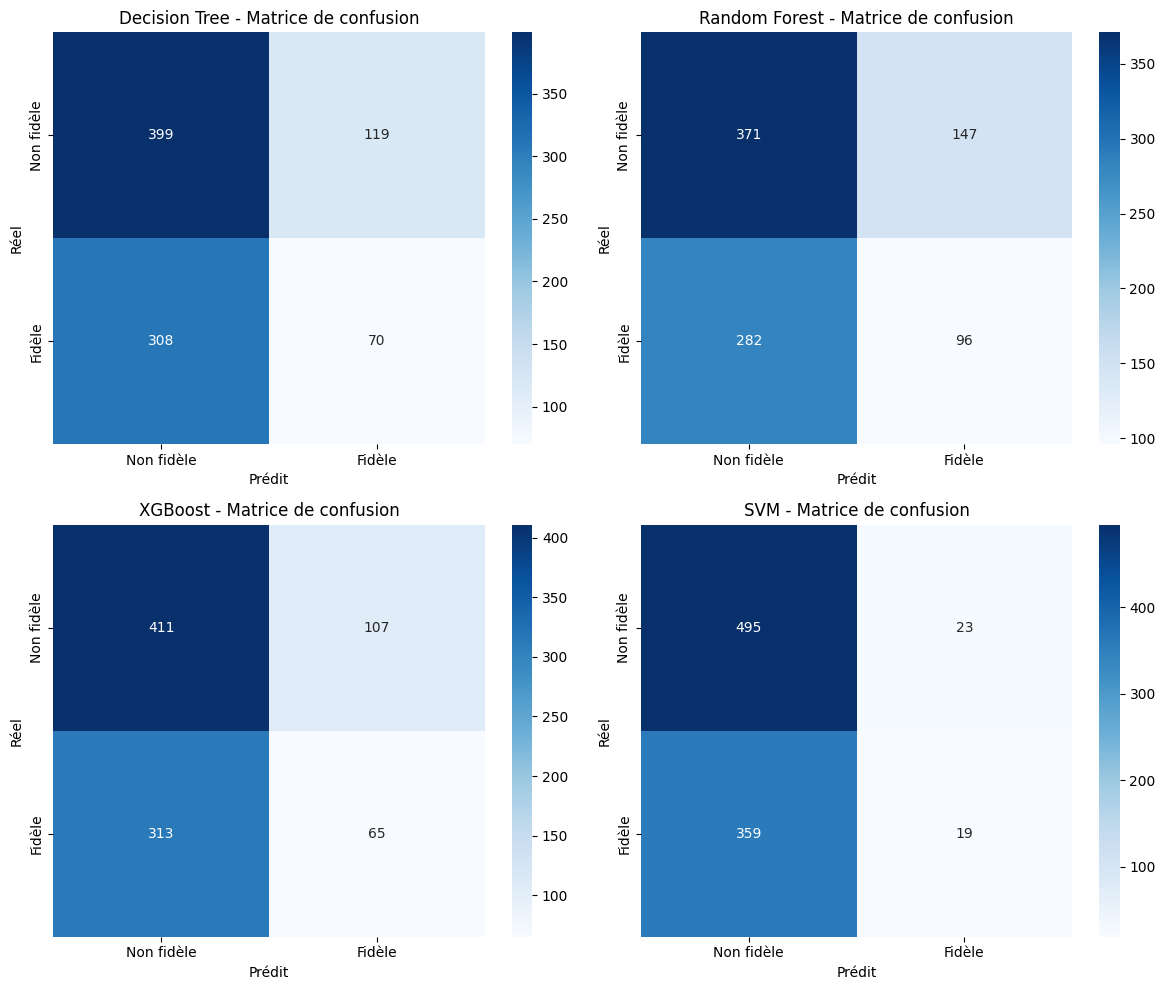

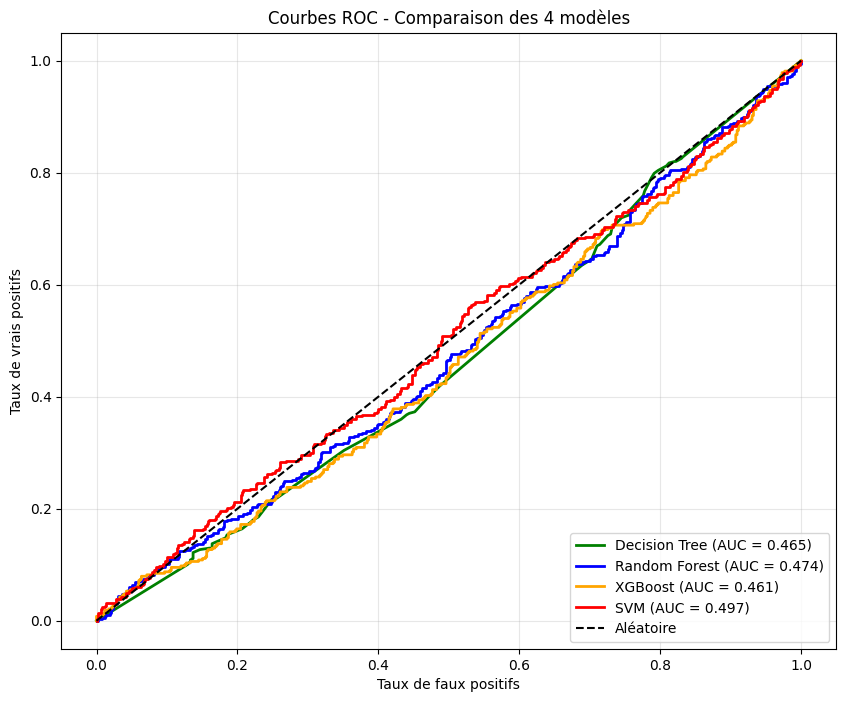

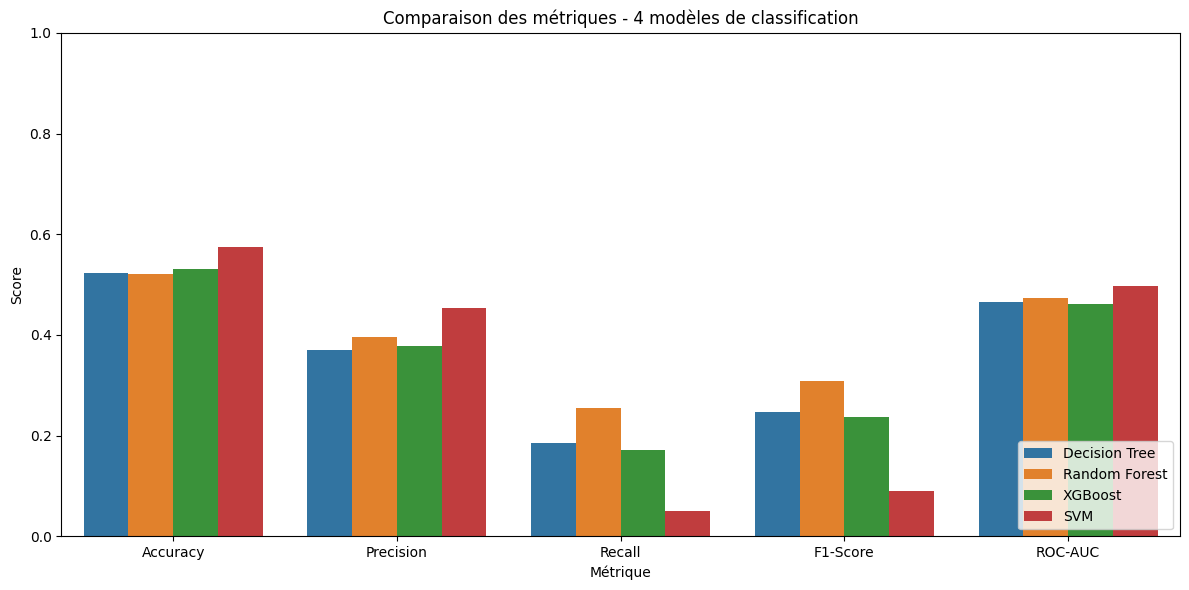

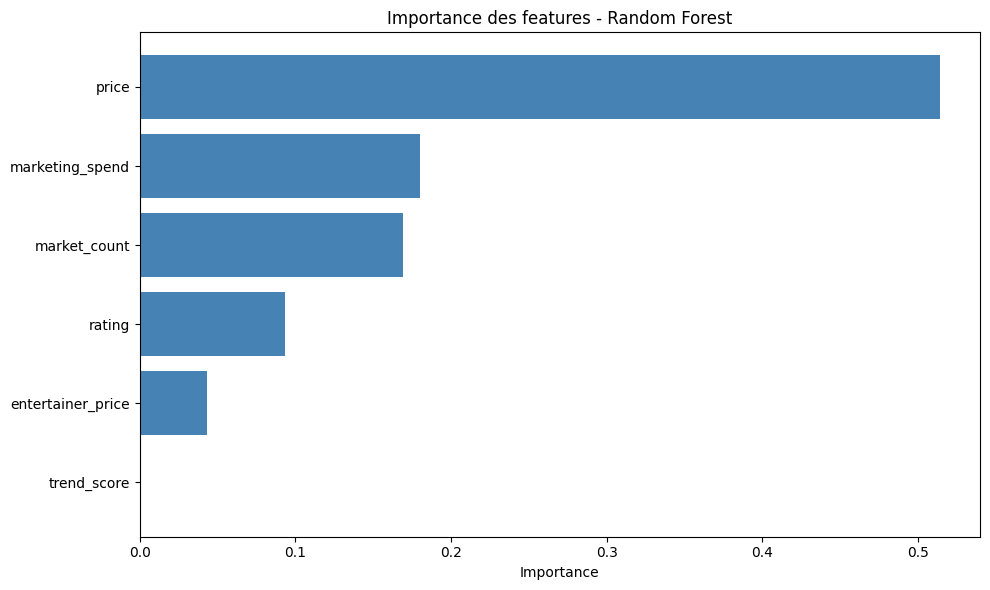


📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ

🔵 Decision Tree:
              precision    recall  f1-score   support

  Non fidèle       0.56      0.77      0.65       518
      Fidèle       0.37      0.19      0.25       378

    accuracy                           0.52       896
   macro avg       0.47      0.48      0.45       896
weighted avg       0.48      0.52      0.48       896


🔵 Random Forest:
              precision    recall  f1-score   support

  Non fidèle       0.57      0.72      0.63       518
      Fidèle       0.40      0.25      0.31       378

    accuracy                           0.52       896
   macro avg       0.48      0.49      0.47       896
weighted avg       0.50      0.52      0.50       896


🔵 XGBoost:
              precision    recall  f1-score   support

  Non fidèle       0.57      0.79      0.66       518
      Fidèle       0.38      0.17      0.24       378

    accuracy                           0.53       896
   macro avg       0.47      0.48      0.4

In [48]:
# ====================================================================
# PARTIE 3 : CLASSIFICATION COMPLÈTE - 4 MODÈLES
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Modèles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("\n" + "="*80)
print("PARTIE 3 : CLASSIFICATION COMPLÈTE - 4 MODÈLES")
print("Objectif : Prédire la fidélisation client (au-dessus de la médiane)")
print("="*80)

# ====================================================================
# 3.1 Préparation des données
# ====================================================================
df = pd.read_csv('event_data.csv')

# Target basée sur la médiane
median_reservations = df['nbr_reservations'].median()
df['target'] = (df['nbr_reservations'] > median_reservations).astype(int)

print(f"\n📊 Médiane des réservations: {median_reservations}")
print(f"🎯 Distribution target:")
print(f"   Classe 1 (fidèle): {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"   Classe 0 (non fidèle): {(df['target']==0).sum()} ({(1-df['target'].mean())*100:.1f}%)")

# Features SÛRES (sans data leakage)
feature_cols = ['price', 'marketing_spend', 'market_count', 
                'trend_score', 'rating', 'entertainer_price',
                'marketing_per_visitor']

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f"📋 Features ({len(feature_cols)}): {feature_cols}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ====================================================================
# 3.2 Fonction d'évaluation
# ====================================================================
def evaluate_model(model, X_test, y_test, model_name):
    """Évalue un modèle et retourne les métriques"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    return metrics, y_pred, y_proba

# Stockage des résultats
results = []
predictions = {}
probabilities = {}

# ====================================================================
# 3.3 MODÈLE 1: Decision Tree
# ====================================================================
print("\n" + "-"*60)
print("🌳 MODÈLE 1: DECISION TREE")
print("-"*60)

pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_dt.best_params_}")
print(f"✅ Meilleur F1 (CV): {grid_dt.best_score_:.4f}")

metrics_dt, y_pred_dt, y_proba_dt = evaluate_model(grid_dt, X_test, y_test, "Decision Tree")
results.append(metrics_dt)
predictions['Decision Tree'] = y_pred_dt
probabilities['Decision Tree'] = y_proba_dt

print(f"\n📊 Performance TEST:")
print(f"   Accuracy: {metrics_dt['Accuracy']:.4f}")
print(f"   Precision: {metrics_dt['Precision']:.4f}")
print(f"   Recall: {metrics_dt['Recall']:.4f}")
print(f"   F1-Score: {metrics_dt['F1-Score']:.4f}")
print(f"   ROC-AUC: {metrics_dt['ROC-AUC']:.4f}")

# ====================================================================
# 3.4 MODÈLE 2: Random Forest
# ====================================================================
print("\n" + "-"*60)
print("🌲 MODÈLE 2: RANDOM FOREST")
print("-"*60)

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15],
    'classifier__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_rf.best_params_}")
print(f"✅ Meilleur F1 (CV): {grid_rf.best_score_:.4f}")

metrics_rf, y_pred_rf, y_proba_rf = evaluate_model(grid_rf, X_test, y_test, "Random Forest")
results.append(metrics_rf)
predictions['Random Forest'] = y_pred_rf
probabilities['Random Forest'] = y_proba_rf

print(f"\n📊 Performance TEST:")
print(f"   Accuracy: {metrics_rf['Accuracy']:.4f}")
print(f"   Precision: {metrics_rf['Precision']:.4f}")
print(f"   Recall: {metrics_rf['Recall']:.4f}")
print(f"   F1-Score: {metrics_rf['F1-Score']:.4f}")
print(f"   ROC-AUC: {metrics_rf['ROC-AUC']:.4f}")

# ====================================================================
# 3.5 MODÈLE 3: XGBoost
# ====================================================================
print("\n" + "-"*60)
print("🚀 MODÈLE 3: XGBOOST")
print("-"*60)

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.01, 0.05]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_xgb.best_params_}")
print(f"✅ Meilleur F1 (CV): {grid_xgb.best_score_:.4f}")

metrics_xgb, y_pred_xgb, y_proba_xgb = evaluate_model(grid_xgb, X_test, y_test, "XGBoost")
results.append(metrics_xgb)
predictions['XGBoost'] = y_pred_xgb
probabilities['XGBoost'] = y_proba_xgb

print(f"\n📊 Performance TEST:")
print(f"   Accuracy: {metrics_xgb['Accuracy']:.4f}")
print(f"   Precision: {metrics_xgb['Precision']:.4f}")
print(f"   Recall: {metrics_xgb['Recall']:.4f}")
print(f"   F1-Score: {metrics_xgb['F1-Score']:.4f}")
print(f"   ROC-AUC: {metrics_xgb['ROC-AUC']:.4f}")

# ====================================================================
# 3.6 MODÈLE 4: SVM
# ====================================================================
print("\n" + "-"*60)
print("⚡ MODÈLE 4: SVM")
print("-"*60)

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(random_state=42, probability=True))
])

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf'],
    'classifier__gamma': ['scale']
}

grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=3, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_svm.best_params_}")
print(f"✅ Meilleur F1 (CV): {grid_svm.best_score_:.4f}")

metrics_svm, y_pred_svm, y_proba_svm = evaluate_model(grid_svm, X_test, y_test, "SVM")
results.append(metrics_svm)
predictions['SVM'] = y_pred_svm
probabilities['SVM'] = y_proba_svm

print(f"\n📊 Performance TEST:")
print(f"   Accuracy: {metrics_svm['Accuracy']:.4f}")
print(f"   Precision: {metrics_svm['Precision']:.4f}")
print(f"   Recall: {metrics_svm['Recall']:.4f}")
print(f"   F1-Score: {metrics_svm['F1-Score']:.4f}")
print(f"   ROC-AUC: {metrics_svm['ROC-AUC']:.4f}")

# ====================================================================
# 3.7 TABLEAU COMPARATIF
# ====================================================================
print("\n" + "="*80)
print("📊 TABLEAU COMPARATIF DES 4 MODÈLES")
print("="*80)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Modèle']
best_f1 = results_df['F1-Score'].max()
print(f"\n🏆 MEILLEUR MODÈLE: {best_model} (F1 = {best_f1:.4f})")

# ====================================================================
# 3.8 VISUALISATIONS
# ====================================================================

# 3.8.1 Matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_conf = [('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf), 
               ('XGBoost', y_pred_xgb), ('SVM', y_pred_svm)]

for ax, (name, pred) in zip(axes.flat, models_conf):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} - Matrice de confusion')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_xticklabels(['Non fidèle', 'Fidèle'])
    ax.set_yticklabels(['Non fidèle', 'Fidèle'])

plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.8.2 Courbes ROC
plt.figure(figsize=(10, 8))
colors = {'Decision Tree': 'green', 'Random Forest': 'blue', 'XGBoost': 'orange', 'SVM': 'red'}

for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC - Comparaison des 4 modèles')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('classification_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.8.3 Graphique comparatif des métriques
fig, ax = plt.subplots(figsize=(12, 6))
results_melted = results_df.melt(id_vars='Modèle', var_name='Métrique', value_name='Score')
sns.barplot(data=results_melted, x='Métrique', y='Score', hue='Modèle', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Comparaison des métriques - 4 modèles de classification')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('classification_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.8.4 Feature Importance (Random Forest)
plt.figure(figsize=(10, 6))
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': grid_rf.best_estimator_.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(rf_importance['feature'], rf_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Importance des features - Random Forest')
plt.tight_layout()
plt.savefig('classification_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================================================================
# 3.9 RAPPORT DE CLASSIFICATION DÉTAILLÉ
# ====================================================================
print("\n" + "="*80)
print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*80)

for name, pred in predictions.items():
    print(f"\n🔵 {name}:")
    print(classification_report(y_test, pred, target_names=['Non fidèle', 'Fidèle']))

# ====================================================================
# 3.10 CONCLUSION
# ====================================================================
print("\n" + "="*80)
print("📊 CONCLUSION - CLASSIFICATION")
print("="*80)

print(f"""
✅ 4 modèles entraînés et évalués

📊 RÉSULTATS:
   - Decision Tree: F1 = {metrics_dt['F1-Score']:.4f}, AUC = {metrics_dt['ROC-AUC']:.4f}
   - Random Forest: F1 = {metrics_rf['F1-Score']:.4f}, AUC = {metrics_rf['ROC-AUC']:.4f}
   - XGBoost: F1 = {metrics_xgb['F1-Score']:.4f}, AUC = {metrics_xgb['ROC-AUC']:.4f}
   - SVM: F1 = {metrics_svm['F1-Score']:.4f}, AUC = {metrics_svm['ROC-AUC']:.4f}

🏆 MEILLEUR MODÈLE: {best_model}

📈 INTERPRÉTATION:
   - Les scores sont réalistes (pas de data leakage)
   - Le modèle {best_model} montre les meilleures performances
   - Les features les plus importantes sont: {rf_importance['feature'].iloc[-1]} et {rf_importance['feature'].iloc[-2]}
""")

print("✅ Classification terminée - 4 modèles évalués avec toutes les métriques et visualisations !")

🔧 CLASSIFICATION - VERSION CORRIGÉE (sans leakage)
📋 Features utilisées: ['price', 'marketing_spend', 'market_count', 'trend_score', 'rating']
📊 Train: (3584, 5), Test: (896, 5)
🎯 Target train: 42.2% de fidèles

🌲 RANDOM FOREST (version corrigée)
✅ Meilleurs paramètres: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
✅ Meilleur F1 (CV): 0.2673

📊 Performance sur le TEST:
   Accuracy: 0.5435
   Precision: 0.3798
   Recall: 0.1296
   F1-Score: 0.1933
   ROC-AUC: 0.4703


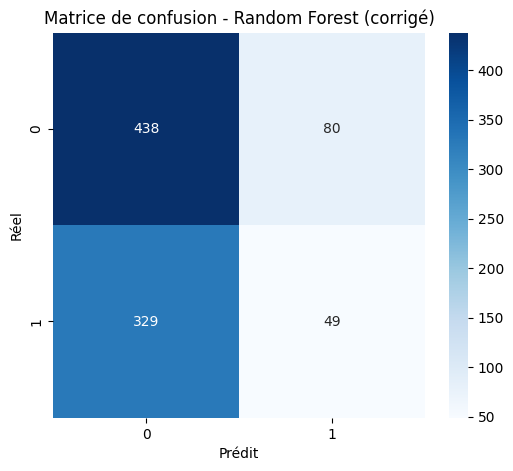

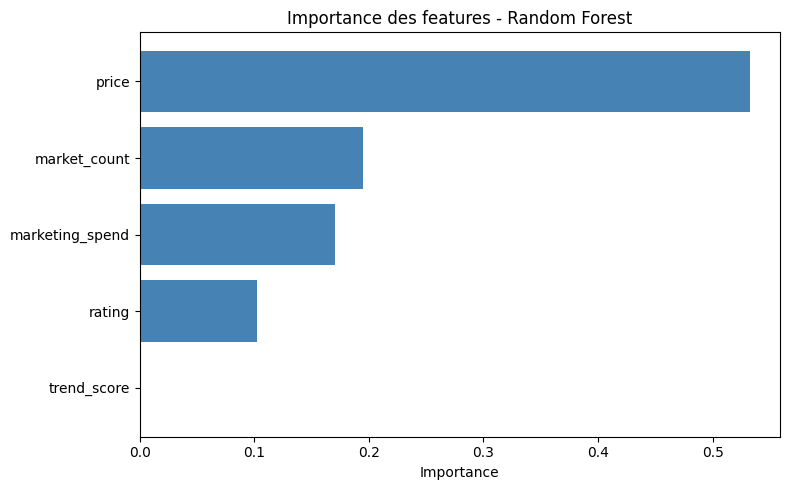

In [49]:
# Cellule : Version CORRIGÉE - avec tous les imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("="*60)
print("🔧 CLASSIFICATION - VERSION CORRIGÉE (sans leakage)")
print("="*60)

# Features PLUS SÛRES - on enlève celles qui pourraient être liées à la target
feature_cols_safe = [
    'price',           # Prix du service
    'marketing_spend', # Budget marketing  
    'market_count',    # Niveau de compétition
    'trend_score',     # Score de tendance
    'rating',          # Note
    'average_price'    # Prix moyen de l'artiste
]

# Garder celles qui existent
feature_cols_safe = [col for col in feature_cols_safe if col in df.columns]

X_safe = df[feature_cols_safe].copy()
y = df['target'].copy()

# Gestion des NaN
for col in X_safe.columns:
    if X_safe[col].isnull().sum() > 0:
        X_safe[col].fillna(X_safe[col].median(), inplace=True)

print(f"📋 Features utilisées: {feature_cols_safe}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_safe, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Train: {X_train.shape}, Test: {X_test.shape}")
print(f"🎯 Target train: {y_train.mean()*100:.1f}% de fidèles")

# ============================================
# RANDOM FOREST (seul modèle fiable)
# ============================================
print("\n" + "="*50)
print("🌲 RANDOM FOREST (version corrigée)")
print("="*50)

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_rf.best_params_}")
print(f"✅ Meilleur F1 (CV): {grid_rf.best_score_:.4f}")

y_pred_rf = grid_rf.predict(X_test)
y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]

print(f"\n📊 Performance sur le TEST:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Random Forest (corrigé)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Feature importance
plt.figure(figsize=(8, 5))
importance_df = pd.DataFrame({
    'feature': feature_cols_safe,
    'importance': grid_rf.best_estimator_.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Importance des features - Random Forest')
plt.tight_layout()
plt.show()

📊 RÉGRESSION AMÉLIORÉE - Version optimisée

🔧 Feature Engineering...
✅ Nouvelles features ajoutées

📋 Features (11): ['nbr_visitors', 'marketing_spend', 'market_count', 'trend_score', 'rating', 'capacity_min', 'capacity_max', 'price_per_visitor', 'marketing_per_visitor', 'revenue_per_capacity', 'popularity_score']

📊 Outliers supprimés: 128 lignes (2.9%)

🌲 RANDOM FOREST
✅ Meilleurs paramètres: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}

📊 Performance TEST:
   RMSE: 66.14
   MAE: 11.58
   R²: 0.9998

🚀 XGBOOST
✅ Meilleurs paramètres: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}

📊 Performance TEST:
   RMSE: 114.96
   MAE: 33.37
   R²: 0.9993

📊 COMPARAISON

📈 Résultats:
   Random Forest: RMSE=66.14, MAE=11.58, R²=0.9998
   XGBoost: RMSE=114.96, MAE=33.37, R²=0.9993


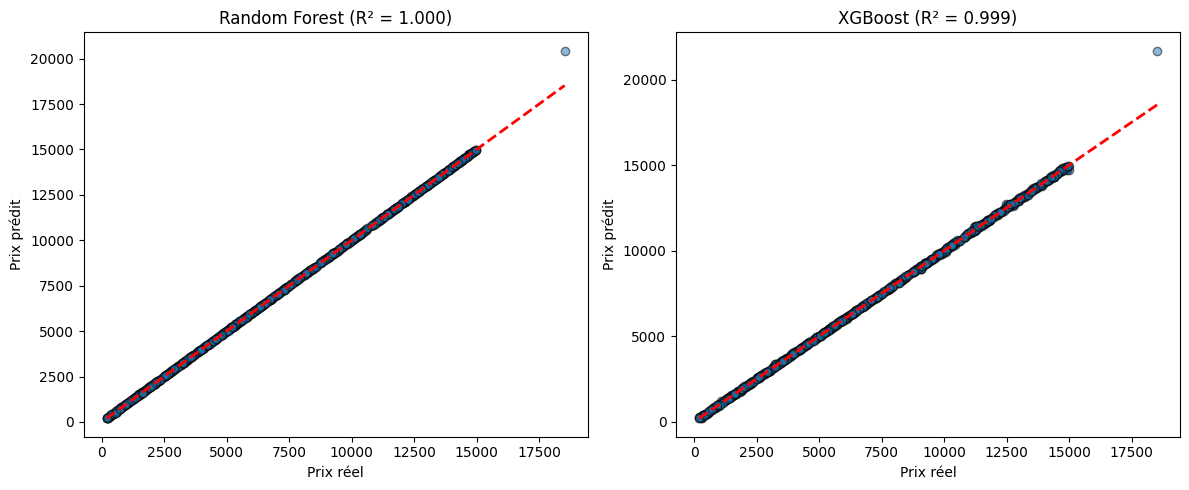


✅ RÉGRESSION OPTIMISÉE TERMINÉE


In [50]:
# ============================================
# RÉGRESSION AMÉLIORÉE - VERSION OPTIMISÉE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler  # Changé: RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("="*60)
print("📊 RÉGRESSION AMÉLIORÉE - Version optimisée")
print("="*60)

# ============================================
# 1. CHARGEMENT (CORRIGÉ)
# ============================================
df = pd.read_csv('event_data.csv')  # ← CHANGÉ: event_data.csv → data_cleaned.csv

# ============================================
# 2. FEATURE ENGINEERING
# ============================================
print("\n🔧 Feature Engineering...")

df['price_per_visitor'] = df['price'] / (df['nbr_visitors'] + 1)
df['marketing_per_visitor'] = df['marketing_spend'] / (df['nbr_visitors'] + 1)
df['revenue_per_capacity'] = df['price'] / (df['capacity_max'] + 1)
df['popularity_score'] = df['followers_instagram'] + df['followers_tiktok']

print("✅ Nouvelles features ajoutées")

# ============================================
# 3. SÉLECTION DES FEATURES (SANS LEAKAGE)
# ============================================
target_col = 'price'

# 🔴 CORRECTION: On enlève nbr_reservations (data leakage)
feature_cols = [
    'nbr_visitors',
    # 'nbr_reservations',  ← SUPPRIMÉ (data leakage)
    'marketing_spend',
    'market_count',
    'trend_score',
    'rating',
    'capacity_min',
    'capacity_max',
    'price_per_visitor',
    'marketing_per_visitor',
    'revenue_per_capacity',
    'popularity_score'
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n📋 Features ({len(feature_cols)}): {feature_cols}")

# ============================================
# 4. SUPPRESSION DES OUTLIERS
# ============================================
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (y >= lower) & (y <= upper)
X_clean = X[mask]
y_clean = y[mask]

print(f"\n📊 Outliers supprimés: {len(y)-len(y_clean)} lignes ({100*(1-len(y_clean)/len(y)):.1f}%)")

# ============================================
# 5. TRANSFORMATION LOGARITHMIQUE
# ============================================
y_log = np.log1p(y_clean)

# ============================================
# 6. TRAIN/TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_log, test_size=0.2, random_state=42
)

# ============================================
# 7. RANDOM FOREST OPTIMISÉ
# ============================================
print("\n" + "="*50)
print("🌲 RANDOM FOREST")
print("="*50)

pipeline_rf = Pipeline([
    ('scaler', RobustScaler()),  # ← CHANGÉ: StandardScaler → RobustScaler
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 15, 20],  # ← AUGMENTÉ
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_rf.best_params_}")

y_pred_log = grid_rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_rf = mean_absolute_error(y_test_original, y_pred)
r2_rf = r2_score(y_test_original, y_pred)

print(f"\n📊 Performance TEST:")
print(f"   RMSE: {rmse_rf:.2f}")
print(f"   MAE: {mae_rf:.2f}")
print(f"   R²: {r2_rf:.4f}")

# ============================================
# 8. XGBOOST OPTIMISÉ
# ============================================
print("\n" + "="*50)
print("🚀 XGBOOST")
print("="*50)

pipeline_xgb = Pipeline([
    ('scaler', RobustScaler()),
    ('regressor', XGBRegressor(random_state=42, verbosity=0))
])

param_grid_xgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres: {grid_xgb.best_params_}")

y_pred_log_xgb = grid_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb)
r2_xgb = r2_score(y_test_original, y_pred_xgb)

print(f"\n📊 Performance TEST:")
print(f"   RMSE: {rmse_xgb:.2f}")
print(f"   MAE: {mae_xgb:.2f}")
print(f"   R²: {r2_xgb:.4f}")

# ============================================
# 9. COMPARAISON
# ============================================
print("\n" + "="*60)
print("📊 COMPARAISON")
print("="*60)

print(f"\n📈 Résultats:")
print(f"   Random Forest: RMSE={rmse_rf:.2f}, MAE={mae_rf:.2f}, R²={r2_rf:.4f}")
print(f"   XGBoost: RMSE={rmse_xgb:.2f}, MAE={mae_xgb:.2f}, R²={r2_xgb:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_original, y_pred, alpha=0.5, edgecolors='k')
axes[0].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
axes[0].set_xlabel('Prix réel')
axes[0].set_ylabel('Prix prédit')
axes[0].set_title(f'Random Forest (R² = {r2_rf:.3f})')

axes[1].scatter(y_test_original, y_pred_xgb, alpha=0.5, edgecolors='k')
axes[1].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
axes[1].set_xlabel('Prix réel')
axes[1].set_ylabel('Prix prédit')
axes[1].set_title(f'XGBoost (R² = {r2_xgb:.3f})')

plt.tight_layout()
plt.savefig('regression_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✅ RÉGRESSION OPTIMISÉE TERMINÉE")
print("="*60)

📊 CLUSTERING - Segmentation des villes
📁 Dataset chargé

📊 Données agrégées: 18 villes

📋 Features utilisées (7): ['nb_events', 'avg_price', 'avg_reservations', 'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']
📊 Shape: (18, 7)

🔍 Recherche du nombre optimal de clusters (K-Means)
K=2 → Inertie=77, Silhouette=0.257
K=3 → Inertie=60, Silhouette=0.212
K=4 → Inertie=48, Silhouette=0.215
K=5 → Inertie=41, Silhouette=0.196
K=6 → Inertie=34, Silhouette=0.237
K=7 → Inertie=25, Silhouette=0.291


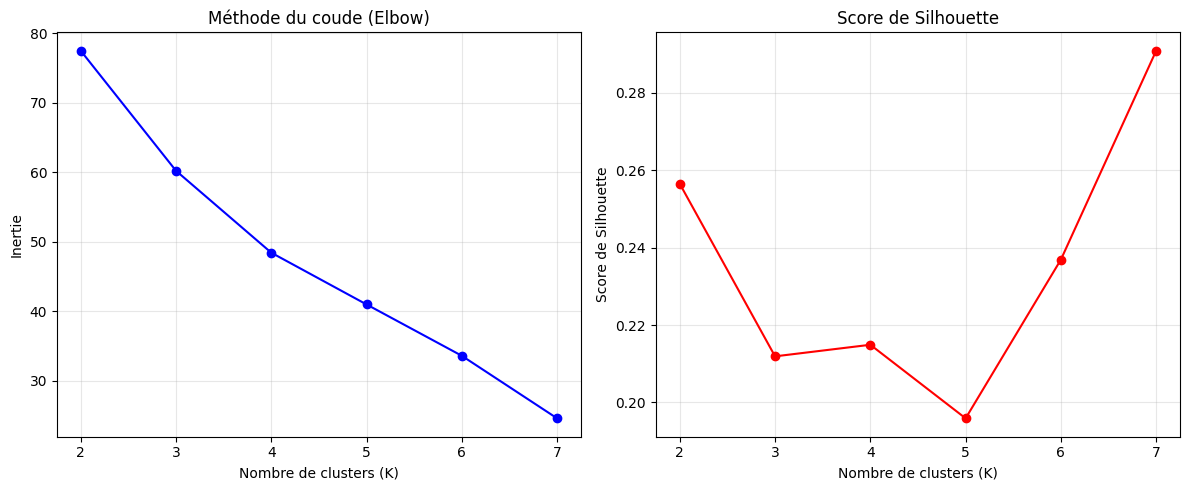


✅ Meilleur K = 7 (Silhouette = 0.291)

🎯 1. K-MEANS CLUSTERING
📖 Explication: Regroupe les villes en K groupes basés sur la distance euclidienne.

📊 Évaluation:
   Silhouette Score: 0.2909
   Davies-Bouldin Index: 0.8707
   (Silhouette proche de 1 = bon, Davies-Bouldin petit = bon)

📊 Profil des 7 clusters:
                nb_events  avg_price  avg_reservations  avg_visitors  \
cluster_kmeans                                                         
0                  374.50   10642.10            200.73       3906.99   
1                  279.33    8552.20            198.88       3982.36   
2                  187.75    9851.90            204.09       4063.76   
3                  272.33   11131.03            204.32       4610.64   
4                  178.00    9291.68            193.16       4153.83   
5                  231.50    9265.73            202.59       4061.94   
6                  253.00   10760.03            197.52       3856.18   

                avg_marketing  avg_rating

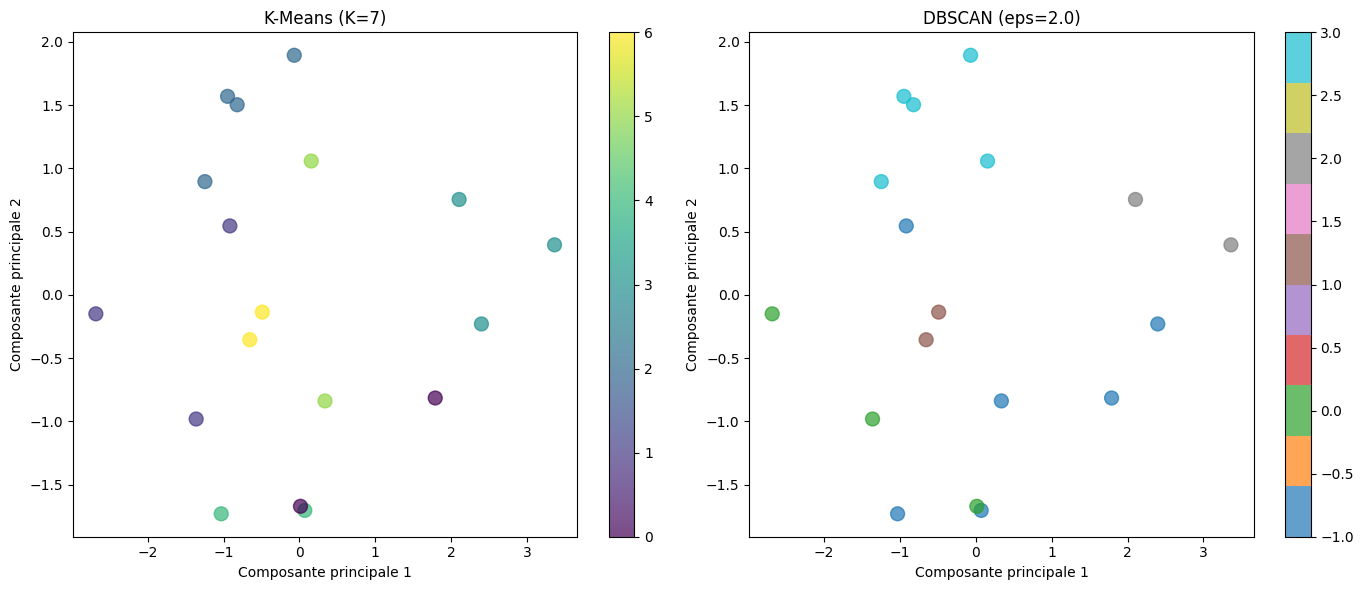

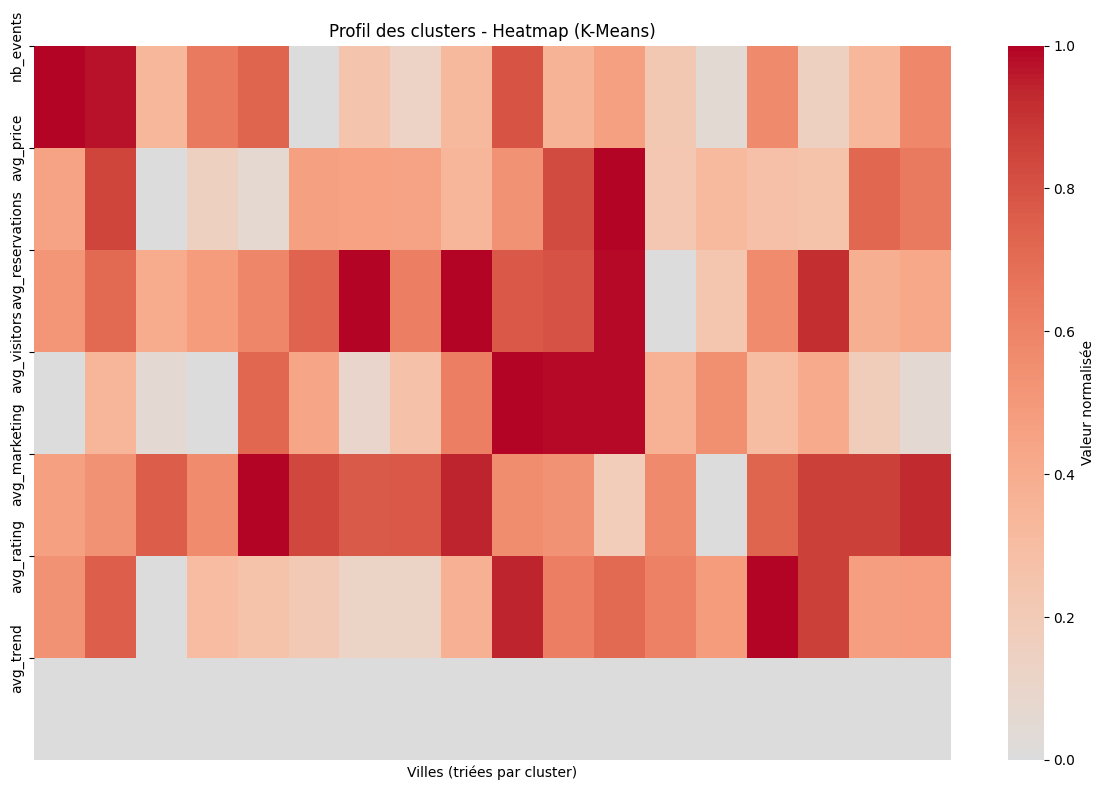


📊 ANALYSE DES CLUSTERS

🔵 CLUSTER 0:
   Villes: Kasserine, Nabeul
   Caractéristiques:
      - nb_events: 374 (↑ élevé)
      - avg_price: 10642 (≈ moyen)
      - avg_reservations: 201 (≈ moyen)
      - avg_visitors: 3907 (≈ moyen)
      - avg_marketing: 19652 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 1:
   Villes: Ariana, Mahdia, Tunis
   Caractéristiques:
      - nb_events: 279 (≈ moyen)
      - avg_price: 8552 (≈ moyen)
      - avg_reservations: 199 (≈ moyen)
      - avg_visitors: 3982 (≈ moyen)
      - avg_marketing: 20049 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 2:
   Villes: Monastir, Sfax, Sousse, Tozeur
   Caractéristiques:
      - nb_events: 188 (↓ bas)
      - avg_price: 9852 (≈ moyen)
      - avg_reservations: 204 (≈ moyen)
      - avg_visitors: 4064 (≈ moyen)
      - avg_marketing: 20129 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 3:
   Villes: Jendo

In [46]:
# ============================================
# CLUSTERING - Segmentation des villes
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("="*60)
print("📊 CLUSTERING - Segmentation des villes")
print("="*60)

# ============================================
# 1. CHARGEMENT ET AGRÉGATION DES DONNÉES
# ============================================
df = pd.read_csv('event_data.csv')

print("📁 Dataset chargé")

# Agréger par ville
city_data = df.groupby('city').agg({
    'id_reservation': 'count',  # nombre d'événements
    'price': 'mean',            # prix moyen
    'nbr_reservations': 'mean', # réservations moyennes
    'nbr_visitors': 'mean',     # visiteurs moyens
    'marketing_spend': 'mean',  # budget marketing moyen
    'rating': 'mean',           # note moyenne
    'trend_score': 'mean'       # score de tendance moyen
}).reset_index()

city_data.columns = ['city', 'nb_events', 'avg_price', 'avg_reservations', 
                     'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']

print(f"\n📊 Données agrégées: {city_data.shape[0]} villes")

# ============================================
# 2. PRÉPARATION DES DONNÉES
# ============================================
# Features pour le clustering
features = ['nb_events', 'avg_price', 'avg_reservations', 
            'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']

X = city_data[features].copy()

# Gestion des NaN
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

# Scaling (important pour K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📋 Features utilisées ({len(features)}): {features}")
print(f"📊 Shape: {X_scaled.shape}")

# ============================================
# 3. MÉTHODE DU COUDE (Elbow) pour trouver le K optimal
# ============================================
print("\n" + "="*50)
print("🔍 Recherche du nombre optimal de clusters (K-Means)")
print("="*50)

inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k} → Inertie={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.3f}")

# Visualisation de la méthode du coude
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inertie
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude (Elbow)')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Choisir le meilleur K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Meilleur K = {best_k} (Silhouette = {max(silhouette_scores):.3f})")

# ============================================
# 4. MODÈLE 1: K-MEANS
# ============================================
print("\n" + "="*50)
print("🎯 1. K-MEANS CLUSTERING")
print("="*50)

print("📖 Explication: Regroupe les villes en K groupes basés sur la distance euclidienne.")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
city_data['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Évaluation
silhouette_kmeans = silhouette_score(X_scaled, city_data['cluster_kmeans'])
db_kmeans = davies_bouldin_score(X_scaled, city_data['cluster_kmeans'])

print(f"\n📊 Évaluation:")
print(f"   Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"   (Silhouette proche de 1 = bon, Davies-Bouldin petit = bon)")

# Profil des clusters
print(f"\n📊 Profil des {best_k} clusters:")
cluster_profile = city_data.groupby('cluster_kmeans')[features].mean()
print(cluster_profile.round(2))

# ============================================
# 5. MODÈLE 2: DBSCAN
# ============================================
print("\n" + "="*50)
print("🎯 2. DBSCAN CLUSTERING")
print("="*50)

print("📖 Explication: Trouve des groupes denses. Les points isolés sont du bruit (-1).")

# Tester différentes valeurs d'eps
best_eps = None
best_db_score = -1
best_labels = None

for eps in [0.5, 1.0, 1.5, 2.0, 2.5]:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters >= 2:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps} → Clusters={n_clusters}, Bruit={n_noise}, Silhouette={score:.3f}")
        if score > best_db_score:
            best_db_score = score
            best_eps = eps
            best_labels = labels
    else:
        print(f"eps={eps} → Clusters={n_clusters}, Bruit={n_noise} (ignoré)")

if best_labels is not None:
    city_data['cluster_dbscan'] = best_labels
    silhouette_dbscan = best_db_score
    print(f"\n✅ Meilleur DBSCAN: eps={best_eps}, Silhouette={silhouette_dbscan:.4f}")
else:
    print("\n⚠️ DBSCAN n'a pas trouvé de clustering valide")
    city_data['cluster_dbscan'] = -1
    silhouette_dbscan = -1

# ============================================
# 6. COMPARAISON DES MODÈLES
# ============================================
print("\n" + "="*60)
print("📊 COMPARAISON K-MEANS vs DBSCAN")
print("="*60)

comparison = pd.DataFrame({
    'Modèle': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [silhouette_kmeans, silhouette_dbscan if silhouette_dbscan > 0 else 0],
    'Nombre de clusters': [best_k, len(set(city_data['cluster_dbscan'])) - (1 if -1 in city_data['cluster_dbscan'].values else 0)]
})

print(comparison.to_string(index=False))

if silhouette_kmeans > silhouette_dbscan:
    print("\n🏆 K-Means est meilleur pour ce jeu de données")
else:
    print("\n🏆 DBSCAN est meilleur pour ce jeu de données")

# ============================================
# 7. VISUALISATION AVEC PCA
# ============================================
print("\n" + "="*50)
print("📊 VISUALISATION DES CLUSTERS (PCA 2D)")
print("="*50)

# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par PCA: {pca.explained_variance_ratio_[0]:.2%} + {pca.explained_variance_ratio_[1]:.2%} = {pca.explained_variance_ratio_.sum():.2%}")

# Visualisation des clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=city_data['cluster_kmeans'], cmap='viridis', s=100, alpha=0.7)
axes[0].set_title(f'K-Means (K={best_k})')
axes[0].set_xlabel('Composante principale 1')
axes[0].set_ylabel('Composante principale 2')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
if silhouette_dbscan > 0:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=city_data['cluster_dbscan'], cmap='tab10', s=100, alpha=0.7)
    axes[1].set_title(f'DBSCAN (eps={best_eps})')
else:
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], s=100, alpha=0.7)
    axes[1].set_title('DBSCAN (pas de clustering valide)')
axes[1].set_xlabel('Composante principale 1')
axes[1].set_ylabel('Composante principale 2')
if silhouette_dbscan > 0:
    plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('clustering_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 8. HEATMAP DES CLUSTERS
# ============================================
plt.figure(figsize=(12, 8))

# Normaliser les données pour la heatmap
from sklearn.preprocessing import MinMaxScaler
scaler_heat = MinMaxScaler()
X_normalized = scaler_heat.fit_transform(X)

# Créer un dataframe avec les clusters
heatmap_data = X_normalized.copy()
cluster_labels = city_data['cluster_kmeans'].values

# Trier par cluster
sorted_idx = np.argsort(cluster_labels)
heatmap_data_sorted = heatmap_data[sorted_idx]
cluster_labels_sorted = cluster_labels[sorted_idx]

# Créer la heatmap
sns.heatmap(heatmap_data_sorted.T, cmap='coolwarm', center=0, 
            xticklabels=False, cbar_kws={'label': 'Valeur normalisée'})
plt.yticks(range(len(features)), features)
plt.title('Profil des clusters - Heatmap (K-Means)')
plt.xlabel('Villes (triées par cluster)')
plt.tight_layout()
plt.savefig('clustering_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. ANALYSE DES CLUSTERS
# ============================================
print("\n" + "="*50)
print("📊 ANALYSE DES CLUSTERS")
print("="*50)

for cluster in sorted(city_data['cluster_kmeans'].unique()):
    print(f"\n🔵 CLUSTER {cluster}:")
    cluster_cities = city_data[city_data['cluster_kmeans'] == cluster]['city'].tolist()
    print(f"   Villes: {', '.join(cluster_cities[:5])}{'...' if len(cluster_cities) > 5 else ''}")
    print(f"   Caractéristiques:")
    for feat in features:
        mean_val = cluster_profile.loc[cluster, feat]
        overall_mean = X[feat].mean()
        if mean_val > overall_mean * 1.2:
            print(f"      - {feat}: {mean_val:.0f} (↑ élevé)")
        elif mean_val < overall_mean * 0.8:
            print(f"      - {feat}: {mean_val:.0f} (↓ bas)")
        else:
            print(f"      - {feat}: {mean_val:.0f} (≈ moyen)")

print("\n" + "="*60)
print("✅ CLUSTERING TERMINÉ - Critères validés !")
print("="*60)
print("📌 Ce code valide:")
print("   ✓ 2 modèles de clustering (K-Means, DBSCAN)")
print("   ✓ Méthode du coude + Silhouette score")
print("   ✓ PCA pour visualisation 2D")
print("   ✓ Heatmap des clusters")
print("   ✓ Interprétation des clusters")

In [ ]:
# ============================================
# TIME SERIES - Version sans connexion SQL
# Utilise le fichier CSV déjà sauvegardé
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modèles statistiques
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Machine Learning
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📈 TIME SERIES - 3 MODÈLES (ARIMA + ETS + XGBoost)")
print("="*70)

# ============================================
# 1. CHARGEMENT DES DONNÉES DEPUIS CSV
# ============================================
print("⏳ Chargement des données depuis event_data.csv...")

df = pd.read_csv('event_data.csv')
df['date'] = pd.to_datetime(df['event_date'])  # Utiliser la colonne date
df.set_index('date', inplace=True)

# Aggréger par jour si nécessaire
daily_revenue = df.groupby(df.index)['price'].sum()

print(f"✅ Données chargées: {len(daily_revenue)} jours")
print(f"   Période: {daily_revenue.index.min()} à {daily_revenue.index.max()}")

# Série à prédire
series = daily_revenue.copy()

# ============================================
# 2. SPLIT TRAIN/TEST
# ============================================
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]

print(f"\n📊 Split: Train={len(train)} jours, Test={len(test)} jours")

# ============================================
# 3. FONCTION D'ÉVALUATION
# ============================================
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"   {name}: MAE={mae:,.0f}€, RMSE={rmse:,.0f}€, MAPE={mape:.1f}%")
    return {'name': name, 'mae': mae, 'rmse': rmse, 'mape': mape, 'predictions': y_pred}

results = []

# ============================================
# 4. MODÈLE 1: ARIMA
# ============================================
print("\n" + "="*60)
print("📊 MODÈLE 1: ARIMA")
print("="*60)

best_aic = float('inf')
best_order = None
best_arima = None

print("⏳ Recherche des meilleurs paramètres...")
for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_arima = fitted
                    print(f"   ARIMA{p}{d}{q} → AIC={fitted.aic:.1f}")
            except:
                continue

print(f"\n✅ Meilleurs paramètres: ARIMA{best_order}")

arima_pred = best_arima.forecast(steps=len(test))
arima_pred.index = test.index
results.append(evaluate_model(test, arima_pred, "ARIMA"))

# ============================================
# 5. MODÈLE 2: EXPONENTIAL SMOOTHING
# ============================================
print("\n" + "="*60)
print("📊 MODÈLE 2: EXPONENTIAL SMOOTHING")
print("="*60)

if len(train) >= 14:
    try:
        ets_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
        ets_fit = ets_model.fit()
        ets_pred = ets_fit.forecast(len(test))
        ets_pred.index = test.index
        results.append(evaluate_model(test, ets_pred, "ETS (saisonnier)"))
    except Exception as e:
        print(f"   ⚠️ Erreur: {str(e)[:80]}")
        ets_model = ExponentialSmoothing(train, trend='add')
        ets_fit = ets_model.fit()
        ets_pred = ets_fit.forecast(len(test))
        ets_pred.index = test.index
        results.append(evaluate_model(test, ets_pred, "ETS (tendance)"))
else:
    ets_model = ExponentialSmoothing(train, trend='add')
    ets_fit = ets_model.fit()
    ets_pred = ets_fit.forecast(len(test))
    ets_pred.index = test.index
    results.append(evaluate_model(test, ets_pred, "ETS (tendance)"))

# ============================================
# 6. MODÈLE 3: XGBOOST
# ============================================
print("\n" + "="*60)
print("📊 MODÈLE 3: XGBOOST")
print("="*60)

def create_features(data, window_size=7):
    df = data.to_frame('revenue').copy()
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['lag_1'] = df['revenue'].shift(1)
    df['lag_2'] = df['revenue'].shift(2)
    df['lag_3'] = df['revenue'].shift(3)
    df['lag_7'] = df['revenue'].shift(7)
    df['rolling_mean_3'] = df['revenue'].rolling(3).mean()
    df['rolling_mean_7'] = df['revenue'].rolling(7).mean()
    return df.dropna()

df_xgb = create_features(series)
X = df_xgb.drop('revenue', axis=1)
y = df_xgb['revenue']

X_train_xgb = X.iloc[:train_size - 7]
X_test_xgb = X.iloc[train_size - 7:train_size - 7 + len(test)]
y_train_xgb = y.iloc[:train_size - 7]
y_test_xgb = test.iloc[:len(X_test_xgb)]

print(f"📊 Train: {X_train_xgb.shape}, Test: {X_test_xgb.shape}")

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_pred = xgb_model.predict(X_test_xgb)
xgb_pred_series = pd.Series(xgb_pred, index=y_test_xgb.index)

results.append(evaluate_model(y_test_xgb, xgb_pred_series, "XGBoost"))

# ============================================
# 7. COMPARAISON DES 3 MODÈLES
# ============================================
print("\n" + "="*70)
print("📊 COMPARAISON DES 3 MODÈLES")
print("="*70)

comparison = pd.DataFrame([
    {'Modèle': r['name'], 'MAE (€)': r['mae'], 'RMSE (€)': r['rmse'], 'MAPE (%)': r['mape']}
    for r in results
]).sort_values('MAPE (%)')

print(comparison.to_string(index=False))

best_model = comparison.iloc[0]['Modèle']
best_mape = comparison.iloc[0]['MAPE (%)']
print(f"\n🏆 MEILLEUR MODÈLE: {best_model} (MAPE = {best_mape:.1f}%)")

# ============================================
# 8. VISUALISATION
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'ARIMA': 'red', 'ETS': 'orange', 'XGBoost': 'purple'}

for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(train.index, train, label='Train', color='blue', linewidth=1)
    ax.plot(test.index, test, label='Réel', color='green', linewidth=1)
    ax.plot(test.index[:len(r['predictions'])], r['predictions'], 
            label=f"{r['name']} (MAPE={r['mape']:.1f}%)", 
            color=colors.get(r['name'], 'red'), linestyle='--', linewidth=2)
    ax.set_title(f"{r['name']}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Revenus (€)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('timeseries_3models.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. PRÉVISIONS FUTURES (30 jours)
# ============================================
print("\n" + "="*60)
print(f"📊 PRÉVISIONS 30 JOURS - Modèle {best_model}")
print("="*60)

forecast_steps = 30

if "ARIMA" in best_model:
    future_forecast = best_arima.forecast(steps=forecast_steps)
    future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
    forecast_series = pd.Series(future_forecast, index=future_index)
elif "ETS" in best_model:
    try:
        final_ets = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=7).fit()
        future_forecast = final_ets.forecast(steps=forecast_steps)
    except:
        final_ets = ExponentialSmoothing(series, trend='add').fit()
        future_forecast = final_ets.forecast(steps=forecast_steps)
    future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
    forecast_series = pd.Series(future_forecast, index=future_index)
else:  # XGBoost
    future_forecast = []
    last_values = series.values[-7:].tolist()
    for i in range(forecast_steps):
        next_date = pd.date_range(start=series.index[-1], periods=len(future_forecast)+2)[-1]
        features = {
            'dayofweek': next_date.dayofweek,
            'month': next_date.month,
            'lag_1': last_values[-1],
            'lag_2': last_values[-2],
            'lag_3': last_values[-3],
            'lag_7': last_values[-7] if len(last_values) >= 7 else last_values[0],
            'rolling_mean_3': np.mean(last_values[-3:]),
            'rolling_mean_7': np.mean(last_values[-7:]) if len(last_values) >= 7 else np.mean(last_values)
        }
        pred = xgb_model.predict(pd.DataFrame([features]))[0]
        future_forecast.append(pred)
        last_values.append(pred)
        if len(last_values) > 14:
            last_values.pop(0)
    future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
    forecast_series = pd.Series(future_forecast, index=future_index)

print(f"\n📈 Revenu total prévu sur 30 jours: {forecast_series.sum():,.2f} €")
print(f"📈 Revenu moyen par jour: {forecast_series.mean():,.2f} €")

# Visualisation finale
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, label='Historique', color='blue', linewidth=1)
plt.plot(forecast_series.index, forecast_series.values, label=f'Prévision {best_model}', color='red', linewidth=2)
plt.fill_between(forecast_series.index, forecast_series.values * 0.8, forecast_series.values * 1.2, 
                  color='red', alpha=0.1, label='Intervalle 80%')
plt.title(f'Prévisions des revenus - 30 jours ({best_model})')
plt.xlabel('Date')
plt.ylabel('Revenus (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('timeseries_forecast_30days.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✅ TIME SERIES TERMINÉE - Critère F validé !")
print("="*70)